## Setup


In [1]:
from __future__ import annotations

import sys
from pathlib import Path
import logging

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
# Add project root to sys.path so `src.*` is importable
PROJECT_ROOT = Path.cwd().parent     # notebook lives in /notebooks, root is one up
sys.path.insert(0, str(PROJECT_ROOT))

from src.data.load import load_raw
from src.data.make_target import build_target

logging.basicConfig(level=logging.INFO, format="%(levelname)s: %(message)s")
sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", 60)

## 1. Load


In [2]:
df = build_target(load_raw())
print('Shape:', df.shape)
print()
print('dtypes value counts:')
print(df.dtypes.value_counts())

INFO: Reading D:\Documents\Intership TSC\Projects\medreadmit-ai\data\raw\diabetes.csv


INFO: Loaded 101766 rows × 50 cols — 374017 NaN values total
INFO: build_target: starting with 101766 rows
INFO: Dropped 2423 expired/hospice encounters — 99343 rows remain
INFO: Positive-class rate (readmitted_30d=1): 0.1139


Shape: (99343, 50)

dtypes value counts:
object    36
int64     13
int32      1
Name: count, dtype: int64


## 2. Target Distribution


readmitted_30d
0    88029
1    11314
Name: count, dtype: int64

Positive-class rate: 0.1139


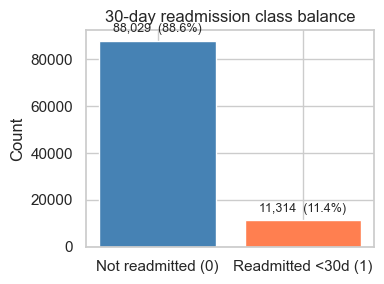

In [3]:
def annotate_bars(ax: plt.Axes, total: int) -> None:
    '''Add count and percentage label above each bar.'''
    for patch in ax.patches:
        count = int(patch.get_height())
        if count == 0:
            continue
        ax.annotate(
            f'{count:,}  ({count / total:.1%})',
            xy=(patch.get_x() + patch.get_width() / 2, patch.get_height()),
            xytext=(0, 4),
            textcoords='offset points',
            ha='center',
            va='bottom',
            fontsize=9,
        )


print(df['readmitted_30d'].value_counts())
print()
rate = df['readmitted_30d'].mean()
print(f'Positive-class rate: {rate:.4f}')

counts = df['readmitted_30d'].value_counts().sort_index()
fig, ax = plt.subplots(figsize=(4, 3))
ax.bar(
    ['Not readmitted (0)', 'Readmitted <30d (1)'],
    counts.values,
    color=['steelblue', 'coral'],
)
annotate_bars(ax, total=len(df))
ax.set_ylabel('Count')
ax.set_title('30-day readmission class balance')
plt.tight_layout()
plt.show()

## 3. Missingness


Top 15 most-missing columns (fraction NaN):
weight               0.968543
max_glu_serum        0.948139
A1Cresult            0.830547
medical_specialty    0.489375
payer_code           0.396586
race                 0.022488
diag_3               0.014284
diag_2               0.003584
diag_1               0.000201
encounter_id         0.000000
troglitazone         0.000000
tolbutamide          0.000000
pioglitazone         0.000000
rosiglitazone        0.000000
acarbose             0.000000


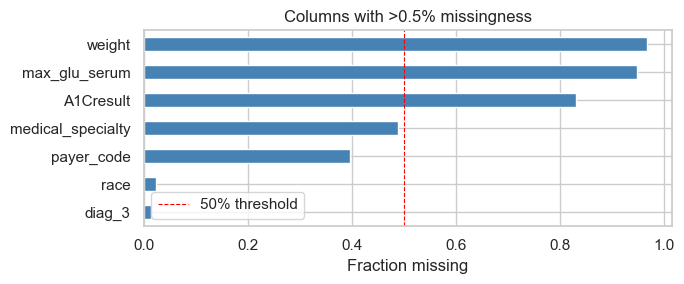

In [4]:
missing = df.isna().mean().sort_values(ascending=False)
print('Top 15 most-missing columns (fraction NaN):')
print(missing.head(15).to_string())

plot_missing = missing[missing > 0.005].sort_values()
fig, ax = plt.subplots(figsize=(7, max(3, len(plot_missing) * 0.4)))
plot_missing.plot.barh(ax=ax, color='steelblue')
ax.axvline(0.5, color='red', linestyle='--', linewidth=0.8, label='50% threshold')
ax.set_xlabel('Fraction missing')
ax.set_title('Columns with >0.5% missingness')
ax.legend()
plt.tight_layout()
plt.show()

`max_glu_serum` and `A1Cresult` missingness is informative — a missing value means the test was not ordered, which is itself a clinical signal. Both will become a `not_measured` category. `weight` (~97% missing) has too little coverage to be useful and will be dropped.


## 4. Patient-Level Leakage Check


In [5]:
n_patients = df['patient_nbr'].nunique()
n_encounters = len(df)
print(f'Unique patients   : {n_patients:,}')
print(f'Total encounters  : {n_encounters:,}')
print(f'Avg enc / patient : {n_encounters / n_patients:.2f}')
print()
print('Encounters per patient (top 10 counts):')
print(df.groupby('patient_nbr').size().value_counts().sort_index().head(10))

Unique patients   : 69,990
Total encounters  : 99,343
Avg enc / patient : 1.42

Encounters per patient (top 10 counts):
1     53649
2     10218
3      3233
4      1354
5       691
6       338
7       192
8       112
9        67
10       41
Name: count, dtype: int64


We must split on `patient_nbr` (GroupShuffleSplit / GroupKFold), not on encounters. Otherwise the same patient appears in train and test, leaking patient-specific patterns and inflating AUROC.


## 5. Numeric Features


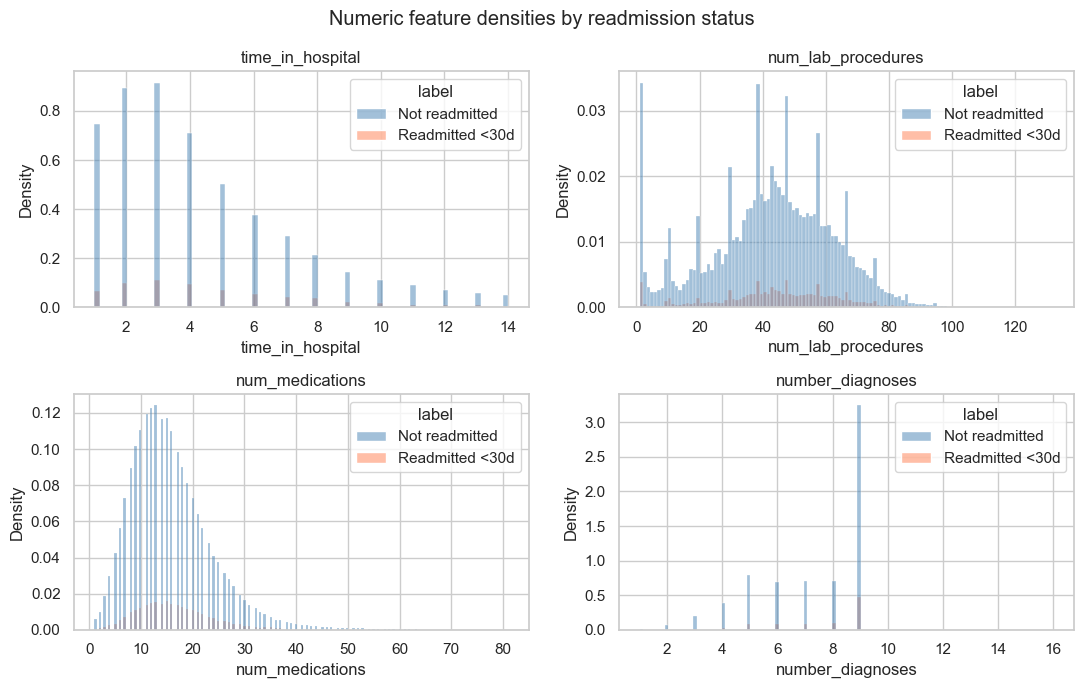

In [6]:
_label_map = {0: 'Not readmitted', 1: 'Readmitted <30d'}
_palette = {'Not readmitted': 'steelblue', 'Readmitted <30d': 'coral'}
_hue_order = ['Not readmitted', 'Readmitted <30d']
num_cols = ['time_in_hospital', 'num_lab_procedures', 'num_medications', 'number_diagnoses']

fig, axes = plt.subplots(2, 2, figsize=(11, 7))
for ax, col in zip(axes.flat, num_cols):
    sns.histplot(
        data=df.assign(label=df['readmitted_30d'].map(_label_map)),
        x=col,
        hue='label',
        hue_order=_hue_order,
        multiple='layer',
        stat='density',
        palette=_palette,
        ax=ax,
    )
    ax.set_title(col)

fig.suptitle('Numeric feature densities by readmission status')
plt.tight_layout()
plt.show()

## 6. Categorical Cardinality


In [7]:
cat_cols = df.select_dtypes('object').columns.tolist()
cardinality = sorted(
    [(col, df[col].nunique()) for col in cat_cols],
    key=lambda x: x[1],
    reverse=True,
)
print('Column'.ljust(35) + 'Unique'.rjust(6))
print('-' * 43)
for col, n in cardinality:
    print(f'{col:<35} {n:>6,}')

Column                             Unique
-------------------------------------------
diag_3                                 786
diag_2                                 747
diag_1                                 715
medical_specialty                       72
payer_code                              17
age                                     10
weight                                   9
race                                     5
metformin                                4
repaglinide                              4
nateglinide                              4
chlorpropamide                           4
glimepiride                              4
glipizide                                4
glyburide                                4
pioglitazone                             4
rosiglitazone                            4
acarbose                                 4
miglitol                                 4
insulin                                  4
glyburide-metformin                      4
gender     

`diag_1`, `diag_2`, `diag_3` each have 700+ unique ICD-9 codes. On Day 3 we bucket these into the 9 Charlson Comorbidity Index categories — using raw codes would create 2000+ one-hot columns and overfit.


## 7. Numeric Correlation with Target


In [8]:
corr = (
    df.select_dtypes(include='number')
    .corr()['readmitted_30d']
    .drop('readmitted_30d')
    .sort_values(key=abs, ascending=False)
)
print('Top 10 features by |r| with readmitted_30d:')
print(corr.head(10).to_string())

Top 10 features by |r| with readmitted_30d:
number_inpatient            0.168326
discharge_disposition_id    0.063374
number_emergency            0.060885
number_diagnoses            0.053580
time_in_hospital            0.046886
num_medications             0.041179
num_lab_procedures          0.024044
number_outpatient           0.019169
admission_type_id          -0.013218
num_procedures             -0.010841


All correlations are weak (|r| < 0.1), which is expected — readmission is multifactorial. The model needs nonlinear feature interactions, which is exactly what gradient boosting captures.
